![](https://aigeekprogrammer.com/wp-content/uploads/2019/08/Handwriting-digit-recognition-Keras-MNIST.jpg)

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
plt.figure(figsize=(15,15))
sns.set_style('darkgrid')
pd.set_option('display.max_rows',100)
pd.set_option('display.max_columns',50)
warnings.filterwarnings('ignore')

<Figure size 1080x1080 with 0 Axes>

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import binarize, Binarizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA

# Loadnig Data

In [3]:
digits_data = pd.read_csv('../input/digit-recognizer/train.csv')
digits_test = pd.read_csv('../input/digit-recognizer/test.csv')
digits_submit = pd.read_csv('../input/digit-recognizer/sample_submission.csv')
digits_data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,...,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


> **It is difficult to see the description of all columns, but at least let's check is there is any null values**

In [4]:
digits_data.columns[digits_data.isna().sum()>0]

Index([], dtype='object')

***Good, there is no missing values (as expected)***

> **Let's check for distribution of labels data**

In [5]:
print(digits_data['label'].value_counts().sort_index())

0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: label, dtype: int64


***It looks normal, almost balanced, and each label have enough data***

# Visualize some random digits

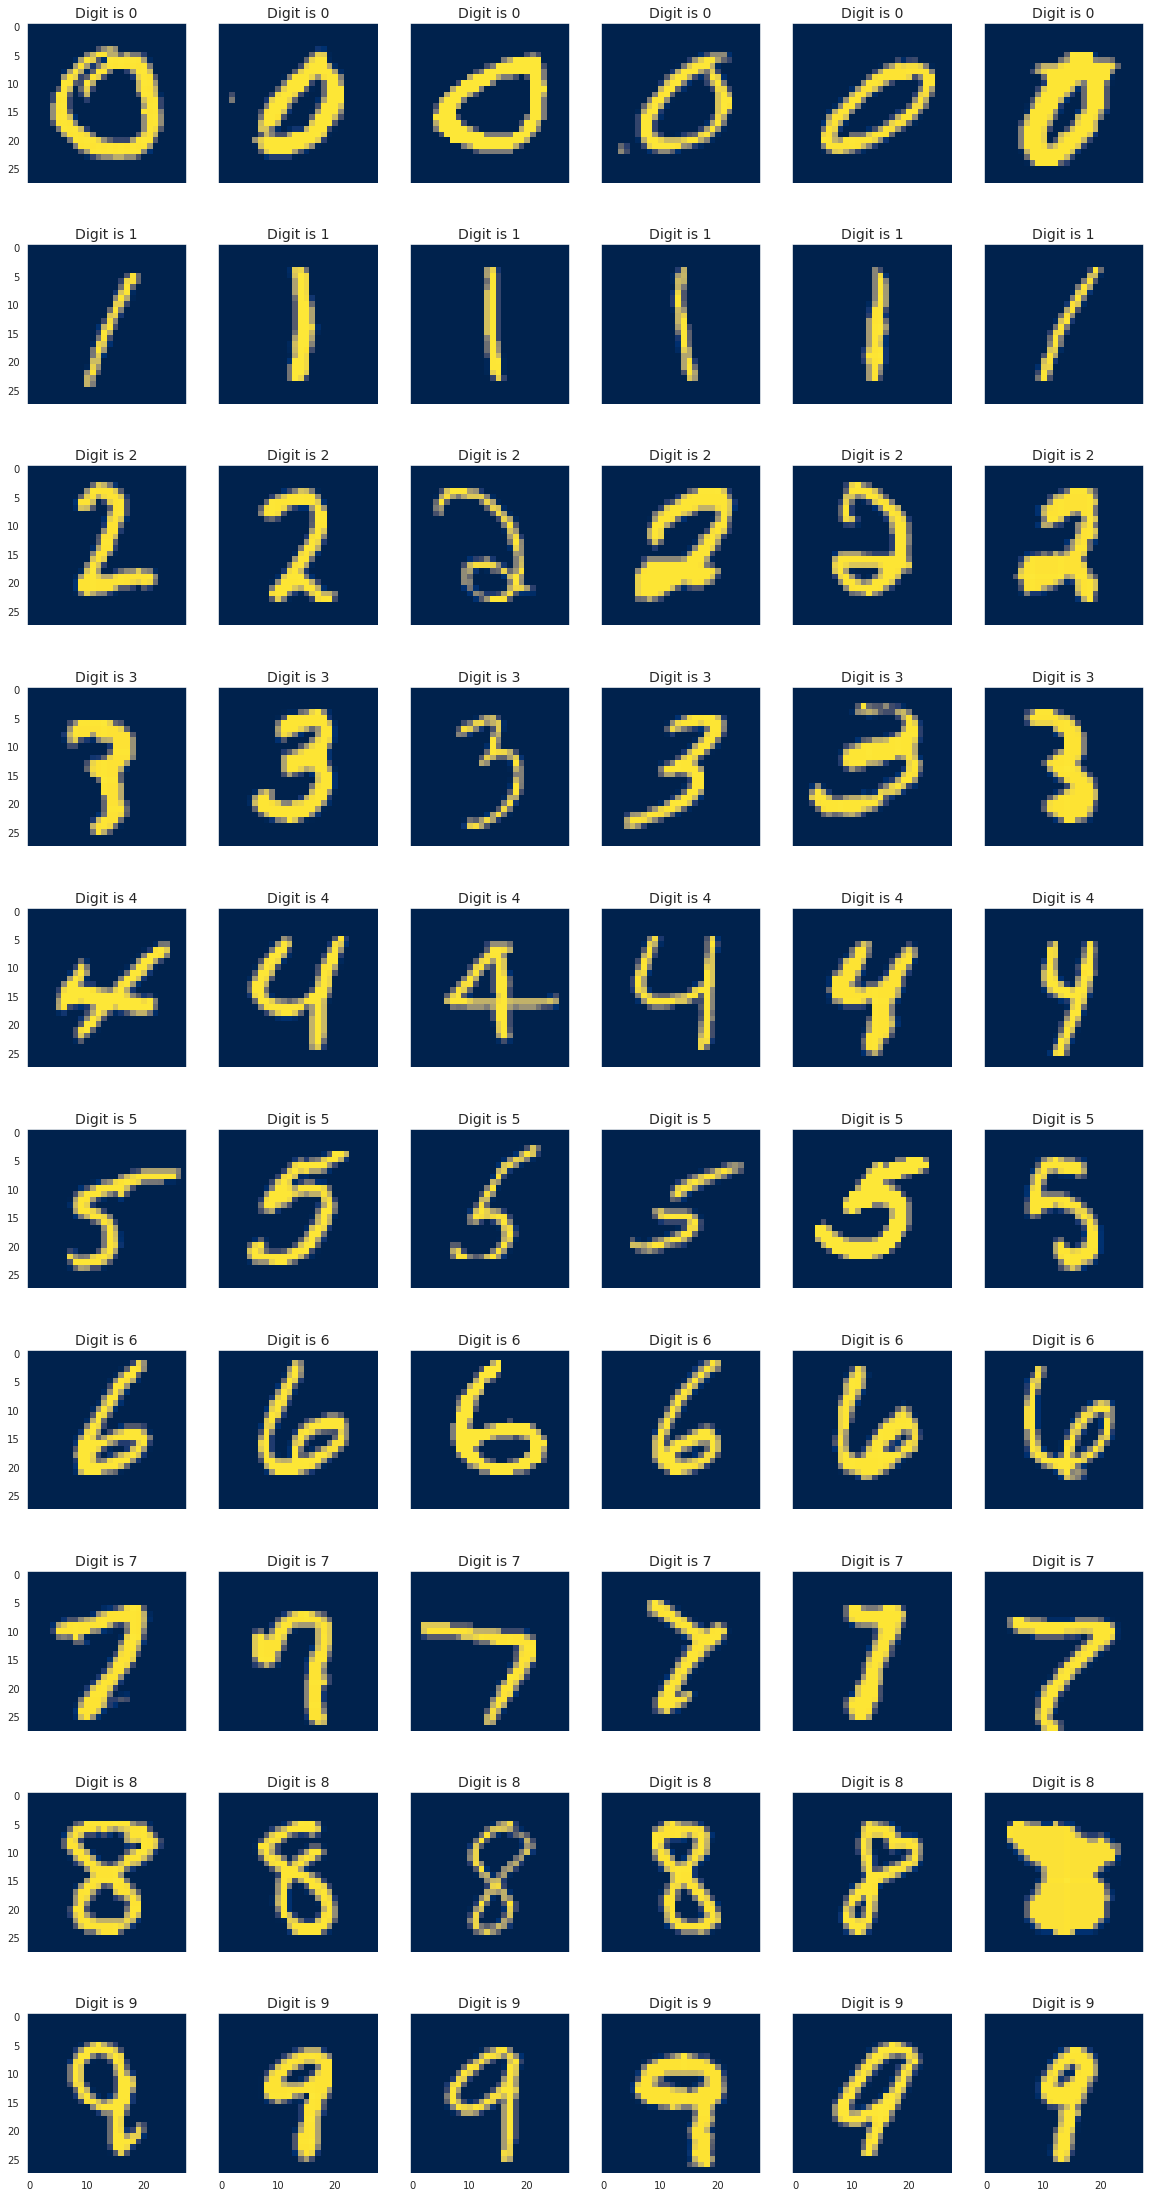

In [6]:
fig, axes = plt.subplots(nrows=10,ncols=6, figsize=(20,40),sharey=True, sharex=True)
idx = 0
for i in range(10):
    for j in (digits_data[digits_data.label==i].sample(n=6).index):
        digit = digits_data['label'].loc[j]
        idx += 1
        plt.subplot(10,6,idx)
        plt.imshow(np.array(digits_data.iloc[j,1:]).reshape(28,28), cmap='cividis')
        plt.title(f'Digit is {digit}',fontsize=14)
        plt.grid(None)
plt.show()

> **There does seem to be some noise around the numbers. Let's check the values of which component the hand drawing**

In [7]:
for k in range(10):
    temp_freq = pd.Series(digits_data.iloc[:,1:].sample(1).T.value_counts(), name='freq')
    print(temp_freq[temp_freq>3])
    print('='*30)

31075
0        587
254       83
Name: freq, dtype: int64
10605
0        590
254       64
2          6
251        4
Name: freq, dtype: int64
37507
0        618
252       46
253       17
137        4
Name: freq, dtype: int64
756
0      586
252     67
253     14
143      7
154      5
176      4
230      4
Name: freq, dtype: int64
25166
0        665
252       45
253        6
Name: freq, dtype: int64
11245
0        657
252       43
253       19
92        10
184        8
Name: freq, dtype: int64
34613
0        668
253       20
254        7
69         4
Name: freq, dtype: int64
5277
0       637
253      35
252      19
254      17
203       7
233       5
151       5
21        4
102       4
50        4
92        4
Name: freq, dtype: int64
9433
0       623
253      53
129       5
Name: freq, dtype: int64
11029
0        673
253       28
254        8
52         5
Name: freq, dtype: int64


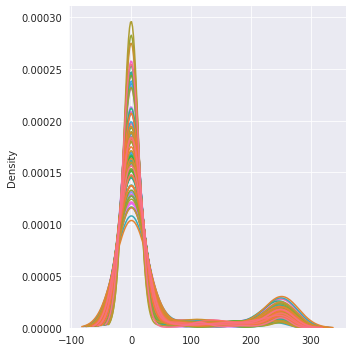

In [8]:
sns.displot(data=digits_data.iloc[:,1:].sample(100).T,kind='kde', legend=False)
plt.show()

> **Ok, it looks like any digit consists of numbers greater than 200 and a very little small numbers**
>
> **Let's binarize all numbers by trying some different thresholds and seeing their efficiency.**

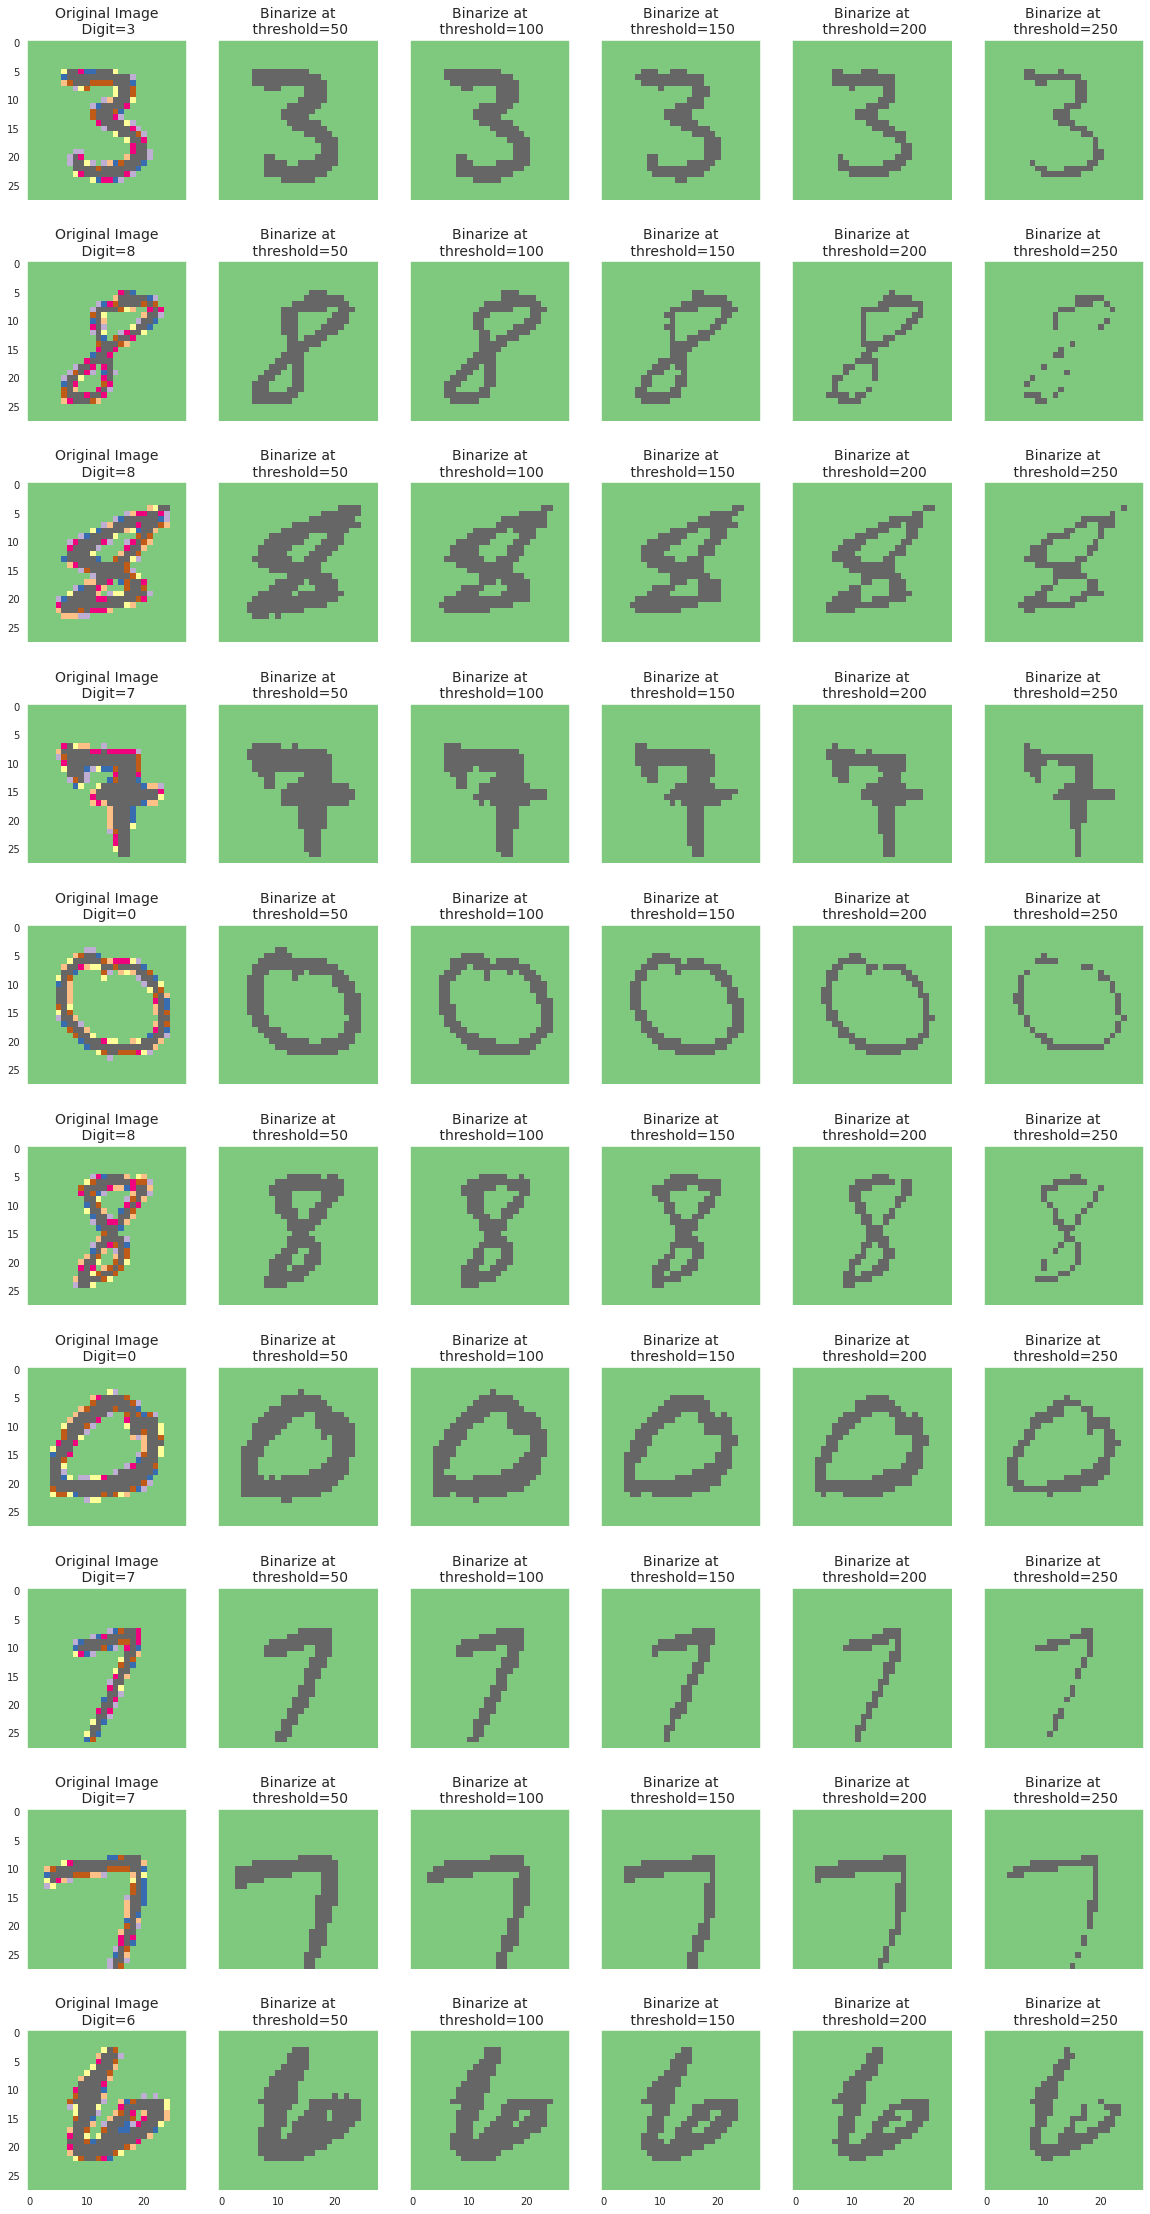

In [9]:
fig, axes = plt.subplots(nrows=10,ncols=6, figsize=(20,40),sharey=True, sharex=True)
idx = 0
for k in np.random.choice(range(42000), 10):
    img = np.array(digits_data.iloc[k,1:]).reshape(28,28)
    idx += 1
    plt.grid(None)        
    plt.subplot(10,6,idx)
    plt.imshow(img, cmap='Accent')
    plt.title(f'Original Image\n Digit={digits_data.iloc[k,0]}',fontsize=14)
    for i in range(1,6):
        idx += 1
        plt.grid(None)    
        plt.subplot(10,6,idx)
        plt.imshow(binarize(img,threshold=i*50), cmap='Accent')
        plt.title(f'Binarize at\n threshold={i*50}',fontsize=14)
plt.show()

> **Good, each threshold has its effect on images. Let's see it in the model.**
>
> **Let's work with the original Data**

# Preprocessing & Modeling

In [10]:
digitsX = digits_data.iloc[:,1:]
digitsY = digits_data.label

> **Most of data are zeros, for better speed and performance let's reduce then 784 feature to only 100 feature by using PCA**

In [11]:
pca = PCA(n_components=100).fit(digitsX)
digits_X_best = pca.transform(digitsX)
digits_test_best = pca.transform(digits_test)

In [12]:
x_train, x_valid, y_train, y_valid = train_test_split(digits_X_best, digitsY, test_size = .25, shuffle=True)
x_train.shape, x_valid.shape

((31500, 100), (10500, 100))

> **After triyng alot of algorithms, i found the SVC is the best result**

In [13]:
print('\n',f' using a 2nd degree polynomial SVC '.center(100,'='),'\n')
svc_model = SVC(kernel='poly', degree=2)
svc_model.fit(x_train, y_train)
ypred = svc_model.predict(x_valid)
print('\n',' confusion_matrix '.center(100,'-'),'\n')
print(confusion_matrix(y_valid, ypred))
print('\n',' classification_report '.center(100,'-'),'\n')
print(print(classification_report(y_valid,ypred)))
print('\n',' accuracy_score '.center(100,'-'),'\n')
print('Accuracy score = ', round(accuracy_score(y_valid,ypred)*100,1),'%')
print('-'*100)


 ================================ using a 2nd degree polynomial SVC ================================= 


 ----------------------------------------- confusion_matrix ----------------------------------------- 

[[1035    0    0    1    0    2    4    0    1    2]
 [   0 1176    4    0    3    0    1    2    0    1]
 [   2    0  986    5    0    0    1    4    9    2]
 [   0    0    8 1070    0   15    0    5    9    6]
 [   2    3    2    1  984    0    0    1    0    9]
 [   1    2    0   13    1  908    4    0    2    4]
 [   5    1    2    0    4    6 1044    0    1    0]
 [   0    4    9    2    3    0    0 1072    0    4]
 [   2    3    6    6    2    6    2    1  966    3]
 [   6    0    2    4    5    5    0    9    4 1020]]

 -------------------------------------- classification_report --------------------------------------- 

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1045
           1       0.99      0.99      0.99  

> **Predicting test data**

In [14]:
ytpred = svc_model.predict(digits_test_best)

# Check some random test Images

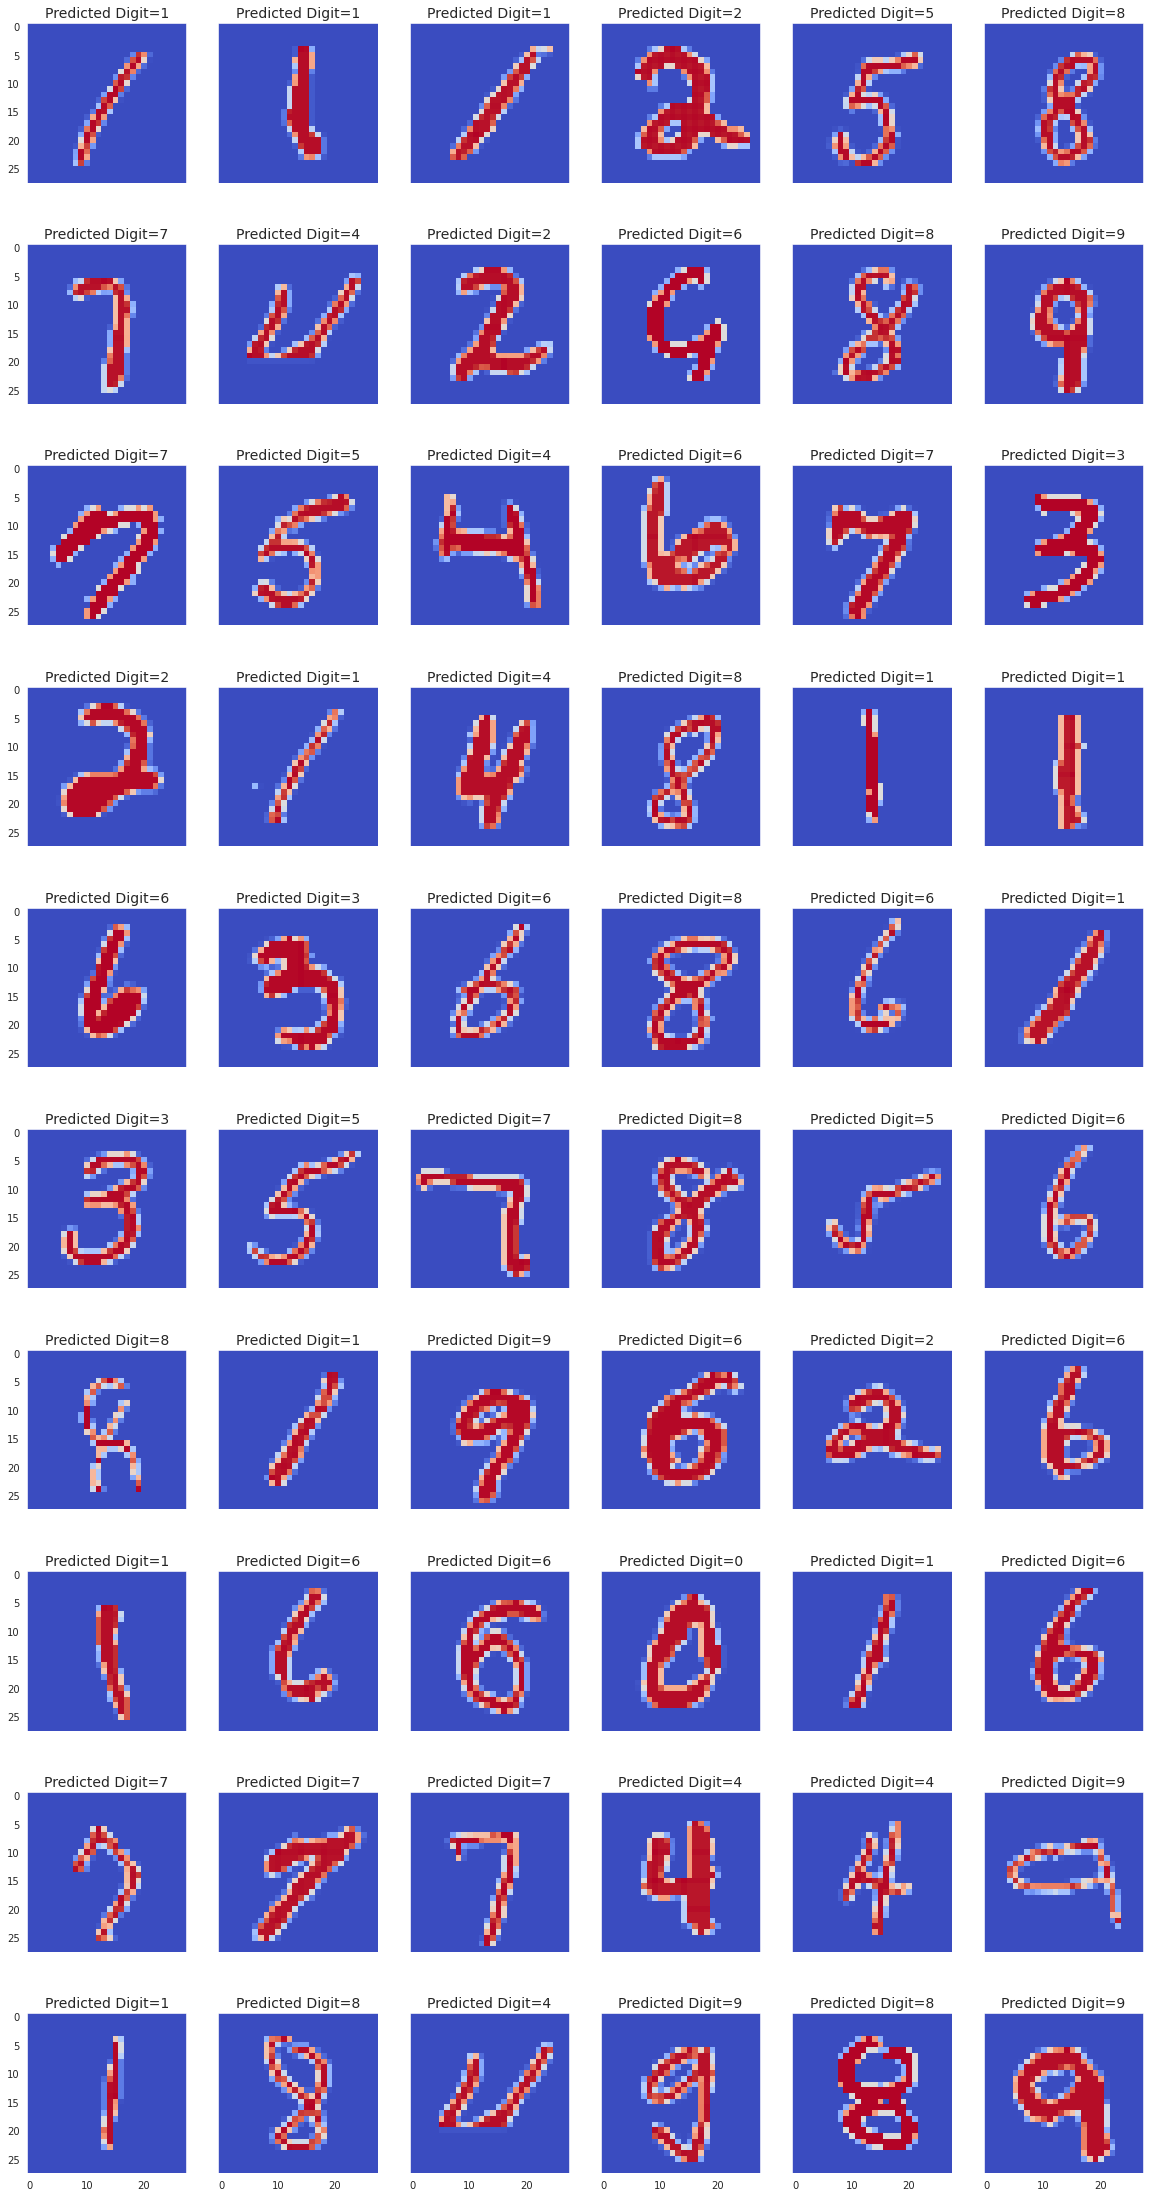

In [15]:
fig, axes = plt.subplots(nrows=10,ncols=6, figsize=(20,40),sharey=True, sharex=True)
idx = 0
for k in np.random.choice(range(28000), 60):
    img = np.array(digits_test.iloc[k,:]).reshape(28,28)
    idx += 1
    plt.grid(None)        
    plt.subplot(10,6,idx)
    plt.imshow(img, cmap='coolwarm')
    plt.title(f'Predicted Digit={ytpred[k]}',fontsize=14)
plt.show()

In [16]:
submit_dict = {'ImageId': range(1,28001), 'label' : pd.Series(ytpred)}
my_submission = pd.DataFrame(submit_dict)
my_submission.to_csv('submission.csv', index=False)

> ***If you like it, please upvote, and feel free to discuss this notebook.***